## Initializing

In [2]:
# Imports
import os, pickle, torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, TextIteratorStreamer
import matplotlib.colors as pltc
import numpy as np
LOCATION = '/igli/raw_logits/'



In [ ]:
# # Reading
# file_no = 1
# with open(os.path.join(LOCATION,f"{file_no:04d}_id_gt.pkl"),   "rb") as f: ID = pickle.load(f).cpu()
# with open(os.path.join(LOCATION,f"{file_no:04d}_id_t.pkl"),    "rb") as f: T_ID = pickle.load(f).cpu()
# with open(os.path.join(LOCATION,f"{file_no:04d}_logit_t.pkl"), "rb") as f: TL = pickle.load(f).cpu()
# with open(os.path.join(LOCATION,f"{file_no:04d}_logit_s.pkl"), "rb") as f: SL = pickle.load(f).cpu()

# emb_file=open(os.path.join(LOCATION,f"{file_no:04d}_emb_s"),    "rb")

In [88]:
# #filter the strings that don't start with a padding
# select=ID[:,0]>0 # these are strings that don't have padding in the beginning
# ID  =ID  [select,:]
# T_ID=T_ID[select,:,:]
# TL  =TL  [select,:,:]
# SL  =SL  [select,:,:]


In [106]:
# # Top 2
# T_ID=T_ID[:,:,0:2]
# TL=TL[:,:,0:2]
# SL=SL[:,:,0:2]


## Preparing the per-token datasets

In [9]:
import os, pickle, torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, TextIteratorStreamer

import matplotlib.colors as pltc
LOCATION = '/igli/raw_logits/'


In [10]:
# Collecting data
l=[]
for file_no in tqdm(range(1,29)):
    with open(os.path.join(LOCATION,f"{file_no:04d}_id_gt.pkl"),   "rb") as f: l.append(pickle.load(f).cpu())
ID=torch.concatenate(l,dim=0)
l=[]
for file_no in tqdm(range(1,29)):
    with open(os.path.join(LOCATION,f"{file_no:04d}_id_t.pkl"),   "rb") as f: l.append(pickle.load(f).cpu())
T_ID = torch.concatenate(l, dim=0)
l=[]
for file_no in tqdm(range(1,29)):
    with open(os.path.join(LOCATION,f"{file_no:04d}_logit_s.pkl"),   "rb") as f: l.append(pickle.load(f).cpu())
SL = torch.concatenate(l, dim=0)
l=[]
for file_no in tqdm(range(1,29)):
    with open(os.path.join(LOCATION,f"{file_no:04d}_logit_t.pkl"),   "rb") as f: l.append(pickle.load(f).cpu())
TL = torch.concatenate(l, dim=0)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:00<00:00, 37.78it/s]


In [11]:
SNL = (torch.softmax(SL, dim=-1) + 0.0001).log()
TNL = (torch.softmax(TL, dim=-1) + 0.0001).log()

In [12]:
residuals = SNL - TNL

In [94]:
class EmbeddingsDataset(torch.utils.data.Dataset):
    def __init__(self, token_id, device, emb_size = 2048):
        self.token_id = token_id
        self.device = device
        self.informations = get_embeddings(self.token_id, embedding_size=emb_size)
        self.data = self.informations['embeddings']
        self.informations['embeddings']= torch.tensor(self.informations['embeddings'])
        for k, v in self.informations.items():
            self.informations[k] = v.to(self.device)
    def __len__(self):
        return self.data.shape[0]
    def __getitem__(self, i):
        emb = torch.tensor(self.informations['embeddings'][i])
        example_id = self.informations['example_id'][i]
        token_pos = self.informations['positions'][i]
        return {"embedding" : emb, "example_id" : example_id, "token_pos" : token_pos}

def read_embedding(file_num, offset, embedding_size):
    arr = np.fromfile(os.path.join(LOCATION,f"{file_num:04d}_emb_s"), dtype='float16', count=embedding_size, offset=offset)
    return arr

def get_embeddings(token_id, embedding_size=2048):
    token_of_interest = token_id
    example_id, token_position = map(torch.squeeze, ((ID[:, 0][..., None] != 0) * (T_ID == token_of_interest).any(dim=-1)).nonzero().split(1, dim=1))
    filenumber = example_id // 1000 + 1
    offsets = token_position * embedding_size
    embeddings = [read_embedding(file_no, offset, embedding_size) for (file_no, offset) in zip(filenumber, offsets)]
    embeddings = np.stack(embeddings)
    matrix_info = {
        'embeddings': embeddings,
        'example_id': example_id,
        'positions' : token_position,
    }
    return matrix_info

def get_targets(model, embeddings):
    logits = model(embeddings)
    probs = torch.softmax(logits, dim=-1)
    normed_logits = probs.log() + 0.0001
    return normed_logits, probs

def collate(data):
    embs = torch.concatenate([x['embedding'].unsqueeze(0) for x in data])
    ids = torch.concatenate([x['example_id'].reshape(-1) for x in  data])
    pos = torch.concatenate([x['token_pos'].reshape(-1) for x in data])
    return {"embedding" : embs, "example_id" : ids, "token_pos" : pos}


In [34]:
import gc
torch.cuda.empty_cache()
gc.collect()

2560

In [18]:
hasattr(gemma2, 'device')

True

In [26]:
del globals()["_16"]

In [18]:
gemma2.device

device(type='cuda', index=1)

In [33]:
[k for k,v in globals().items() if hasattr(v, 'device') and  v.device == torch.device('cuda:1')]

['gemma2']

In [48]:
import gc
[x for x in gc.get_objects() if torch.is_tensor(x) and x.device == torch.device('cuda:1')]

/home/igli/.local/lib/python3.10/site-packages/torch/distributed/distributed_c10d.py:366: UserWarning: torch.distributed.reduce_op is deprecated, please use torch.distributed.ReduceOp instead
  warnings.warn(


ReferenceError: weakly-referenced object no longer exists

# the distribution of logits

## Plots

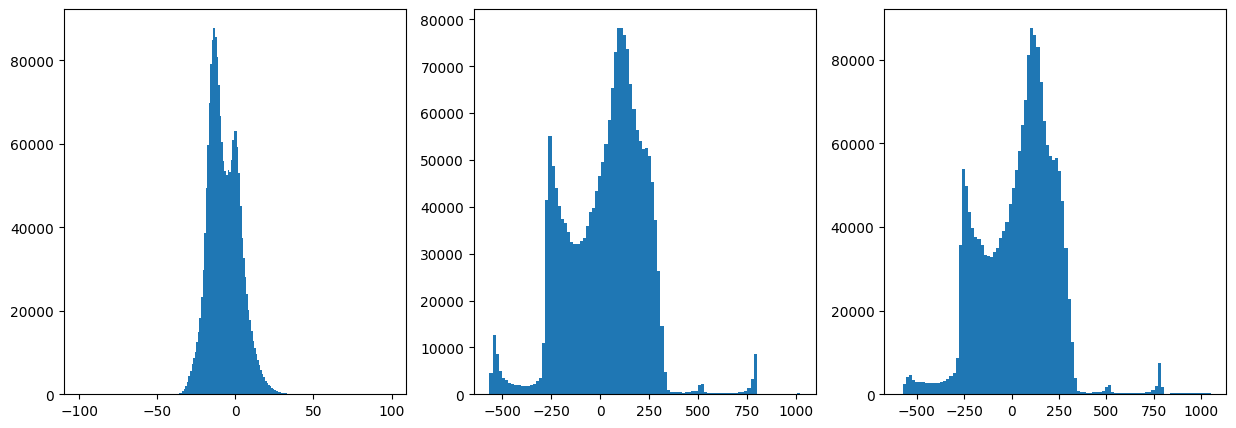

In [107]:
# Initial top 2 logit distribution
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(SL.reshape(-1).numpy(),bins=np.arange(-100,100));
plt.subplot(1,3,2)
plt.hist(TL.reshape(-1).numpy(),bins=100);
plt.subplot(1,3,3)
plt.hist((TL-SL).reshape(-1).numpy(),bins=100);


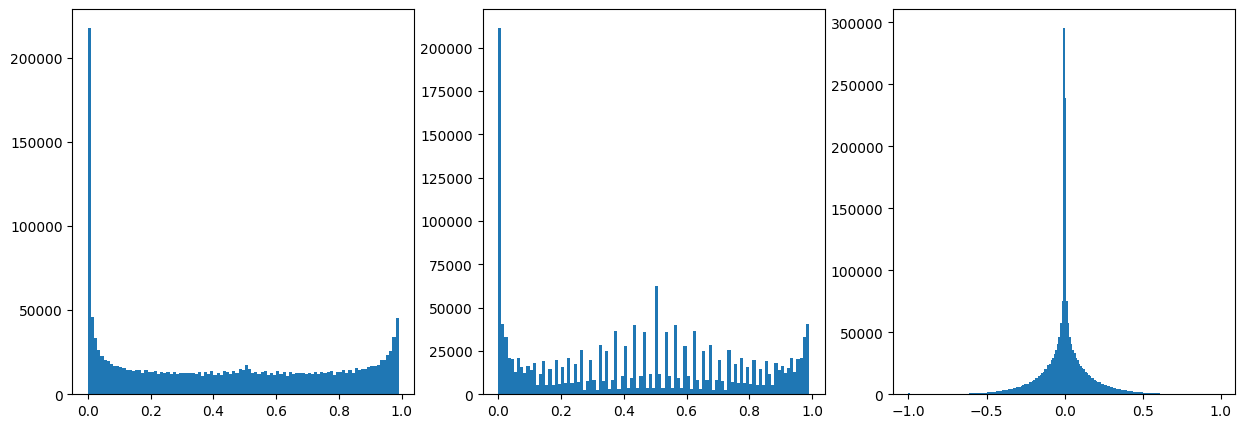

In [108]:
# Distibutions of the top 2 probabilities
SP=torch.softmax(SL,dim=2)
TP=torch.softmax(TL,dim=2)
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(SP.reshape(-1).numpy(),bins=np.arange(0,1,0.01));
plt.subplot(1,3,2)
plt.hist(TP.reshape(-1).numpy(),bins=np.arange(0,1,0.01));
plt.subplot(1,3,3)
plt.hist((TP-SP).reshape(-1).numpy(),bins=np.arange(-1,1,0.01));


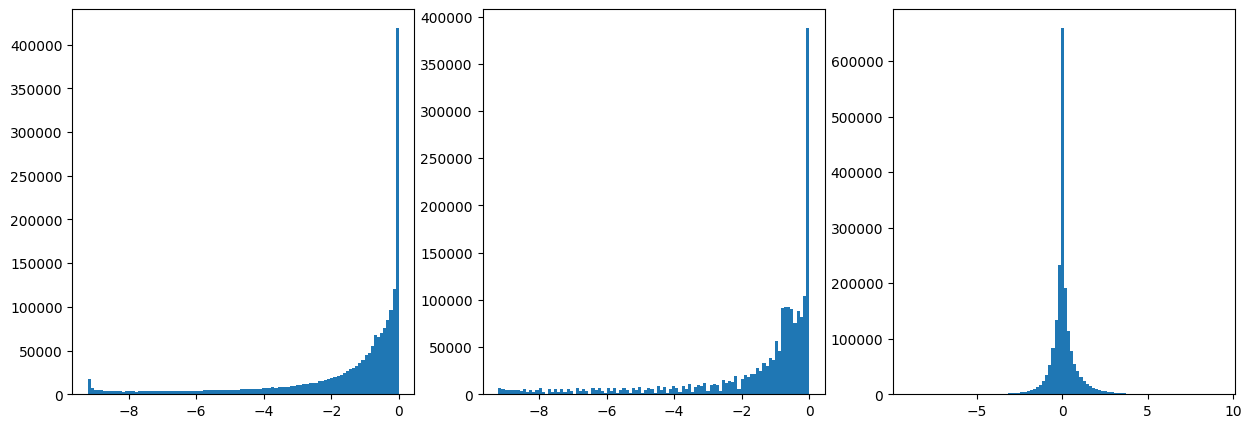

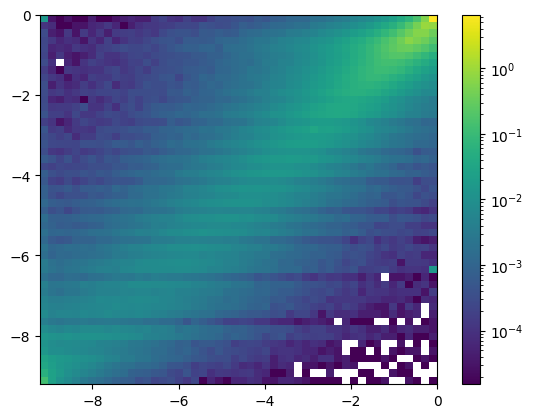

In [123]:
# Distribution of the 'normalized' top 2 logits
SNL=torch.log(SP+0.0001)
TNL=torch.log(TP+0.0001)
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(SNL.reshape(-1).numpy(),bins=100);
#plt.yscale('log')
plt.subplot(1,3,2)
plt.hist(TNL.reshape(-1).numpy(),bins=100);
#plt.yscale('log')
plt.subplot(1,3,3)
plt.hist((TNL-SNL).reshape(-1).numpy(),bins=100);
#plt.yscale('log')
plt.figure()
# plt.scatter(SNL.reshape(-1).numpy(),TNL.reshape(-1).numpy(),alpha=0.02,s=1)
plt.hist2d(SNL.reshape(-1).numpy(),TNL.reshape(-1).numpy(),
                         bins=50, range=None, density=True,  norm=pltc.LogNorm());
plt.colorbar()

In [127]:
select=(TNL/2+SNL/2).reshape(-1)>-2

(TNL-SNL).reshape(-1)[select].std()

tensor(0.8589, dtype=torch.float16)

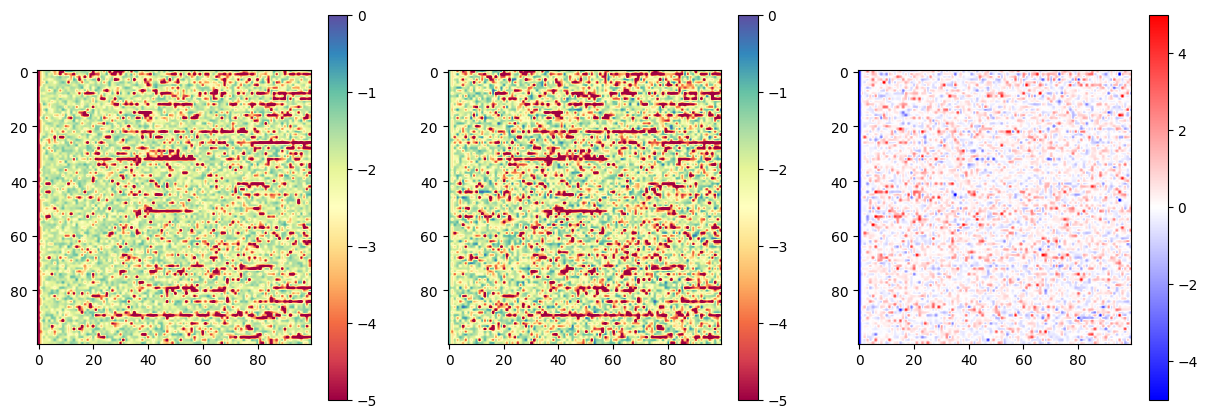

In [103]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(TNL[:,:,1].cpu()[0:100,0:100],cmap='Spectral',vmin=-5,vmax=0)
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(SNL[:,:,1].cpu()[0:100,0:100],cmap='Spectral',vmin=-5,vmax=0)
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow((TNL-SNL)[:,:,1].cpu()[0:100,0:100],cmap='bwr',vmin=-5,vmax=5)
plt.colorbar()

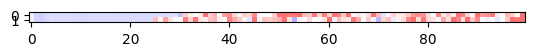

In [83]:
plt.imshow((TNL-SNL).mean(dim=2).cpu()[37:39,0:100],cmap='bwr',vmin=-5,vmax=5)


In [85]:
select=ID[:,0]>0 # these are strings that don't have padding in the beginning

tensor([235345, 235345, 235345, 235345, 235345, 235345,   7026, 235256, 167433,
        235340,   1620,  20191, 235345, 235345,      0,   2795, 235345, 235345,
          1620, 235345, 235345,      0, 235345, 235345, 235345, 105468,  14519,
          4882, 126109, 235345, 235345, 235345, 235345, 235345, 235345, 235345,
        235345,      0,      0, 235345,   1620, 235345,      0,   1620, 235345,
        235345,  11863, 235345,  10328,  11863, 235345,  87699, 235345, 235345,
             0, 235345, 235345, 235345,    886,  11863, 235345,   8320,    651,
        235345, 235345, 235345, 235345, 235345,    108, 235345,  34039,      0,
          2299, 235345,   1620, 235345,   1620, 235345,      0, 235345,   1620,
        235345,   2504, 235345, 235345, 235345, 235345, 235340, 235345, 235345,
          2299, 235345, 235345, 235345,  87699,   1620, 235345,   1620, 235345,
          1620, 235345, 235345, 235345,  10142, 235345, 235345, 235345, 235345,
          2495, 235345, 235345,  10278, 

## distribution of IDs

In [4]:
ID = np.fromfile(os.path.join("/igli/raw_logits_v2",f"{0:04d}_id_gt"),  dtype=np.int32)

In [9]:
ID.reshape(-1, 1024).shape

(1000, 1024)

In [13]:
unique, counts = np.unique(ID, return_counts=True)

In [15]:
a = np.arange(10)
a[[0,1,2,3]] += a[[9,9,7, 6]]

array([ 9, 10,  9,  9,  4,  5,  6,  7,  8,  9])

In [17]:
# Collecting data
l=[]
LOCATION = '/igli/raw_logits_v2'
COUNTS = np.zeros(256000)

for file_no in tqdm(range(0,2662)):
    id = np.fromfile(os.path.join(LOCATION,f"{file_no:04d}_id_gt"),  dtype=np.int32)
    unique, counts = np.unique(id, return_counts=True)
    COUNTS[unique] += counts
l=[]
# for file_no in tqdm(range(1,29)):
#     with open(os.path.join(LOCATION,f"{file_no:04d}_id_t.pkl"),   "rb") as f: l.append(pickle.load(f).cpu())
# T_ID = torch.concatenate(l, dim=0)

100%|██████████| 2662/2662 [00:47<00:00, 55.89it/s]


In [31]:
COUNTS[IX[:10000]].sum()


2495556998.0

In [323]:
import numpy as np
unique, counts = np.unique(ID.reshape(-1).numpy(), return_counts=True);

In [18]:
IX=np.argsort(-COUNTS)

In [325]:
unique

array([     0,      1,      2, ..., 255978, 255979, 255981], dtype=int32)

In [21]:
COUNTS.shape

(256000,)

In [22]:
IX[:10000]

array([235265,    573, 235269, ...,   1779,   2579, 211545])

In [20]:
COUNTS[IX], IX

(array([85275940., 79938036., 76478628., ...,        0.,        0.,
               0.]),
 array([235265,    573, 235269, ...,     57,     56,     22]))

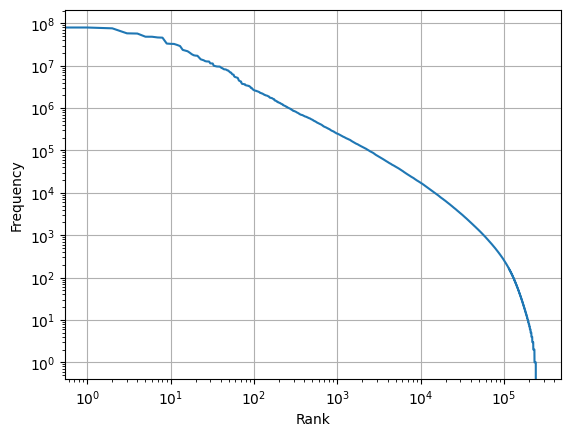

In [24]:
plt.plot(COUNTS[IX])
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.grid()

In [6]:
torch.set_grad_enabled(False)

In [27]:
IX[:10]

array([235265,    573, 235269, 235274, 235248,    109, 235276, 235284,
          576,    476])

In [25]:
tokenizer = AutoTokenizer.from_pretrained('google/gemma-7b')

In [26]:
chop = 10000
[(tokenizer.convert_ids_to_tokens([x]), x) for x in IX[:chop]]

[(['.'], 235265),
 (['▁the'], 573),
 ([','], 235269),
 (['1'], 235274),
 (['▁'], 235248),
 (['\n\n'], 109),
 (['0'], 235276),
 (['2'], 235284),
 (['▁of'], 576),
 (['▁a'], 476),
 (['▁to'], 577),
 (['\n'], 108),
 (['▁and'], 578),
 (['▁is'], 603),
 (['-'], 235290),
 (['3'], 235304),
 (['▁in'], 575),
 ([':'], 235292),
 (['▁('], 591),
 ([')'], 235275),
 (['4'], 235310),
 (['5'], 235308),
 (['▁that'], 674),
 (['▁\\'], 730),
 (['▁for'], 604),
 (['_'], 235298),
 (['6'], 235318),
 (['('], 235278),
 (['{'], 235282),
 (['9'], 235315),
 (['8'], 235321),
 (['7'], 235324),
 (['▁$'], 697),
 (['▁I'], 590),
 (['▁='], 589),
 (['▁are'], 708),
 (['▁with'], 675),
 (['$'], 235323),
 (['▁be'], 614),
 (["'"], 235303),
 (['▁it'], 665),
 (['\\'], 235286),
 (['▁on'], 611),
 (['▁you'], 692),
 (['▁this'], 736),
 (['x'], 235297),
 (['▁as'], 685),
 (['/'], 235283),
 (['s'], 235256),
 (['}'], 235270),
 (['▁by'], 731),
 (['\xa0'], 236338),
 (['▁The'], 714),
 (['▁can'], 798),
 (['▁at'], 696),
 (['▁an'], 671),
 (['▁we']

## Fitting into the residuals

In [109]:
# Residuals 
print(Y[:5],'\t\t\t\t', Y.shape)
# Probabilities
print(P[:5], '\t\t\t\t',P.shape)
# Embeddings
X = token_7257_data.informations['embeddings']
print(X[:5], '\t', X.shape)

X=torch.tensor(X).to(torch.float32)
Y=torch.tensor(Y).to(torch.float32)

tensor([-0.0312,  0.3184,  0.2734, -1.3281, -0.5449], dtype=torch.float16) 				 torch.Size([58237])
tensor([2.3007e-05, 2.5421e-02, 2.5177e-03, 6.3324e-03, 3.3905e-02],
       dtype=torch.float16) 				 torch.Size([58237])
[[-9.3750e-01 -9.6924e-01 -7.8809e-01 ... -3.3569e-01  8.2568e-01
   1.1553e+00]
 [ 3.6743e-01  1.0459e+00 -5.4199e-01 ... -1.1582e+00 -9.4531e-01
   3.3086e+00]
 [ 6.4209e-01 -1.7224e-01  6.2012e-02 ... -7.1826e-01  4.1382e-01
   1.0068e+00]
 [ 1.9751e-01  1.4717e+00  4.2212e-01 ... -1.0157e-03  4.5502e-02
   1.5205e+00]
 [ 7.8027e-01  4.6051e-02  1.6504e-01 ...  2.5220e-01  4.3018e-01
  -7.1826e-01]] 	 (58237, 2048)


/tmp/ipykernel_2031236/3246798746.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y=torch.tensor(Y).to(torch.float32)


In [ ]:
XA=Y
X\X A = X \ Y
A = X \ Y

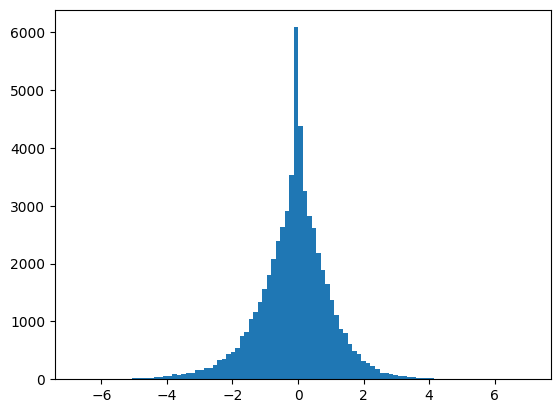

In [152]:
plt.hist(Y.numpy(),bins=100);

In [177]:
X2=X-X.mean(dim=0)
# X2=X2/X.std(dim=0)
A=torch.linalg.lstsq(X2,Y).solution

In [120]:
Y*P

tensor([-7.1898e-07,  8.0931e-03,  6.8843e-04,  ..., -7.9570e-03,
        -1.7658e-03, -1.5846e-02])

In [121]:
X@A

tensor([ 0.0048, -0.0797,  0.0251,  ...,  0.0699,  0.0120,  0.0041])

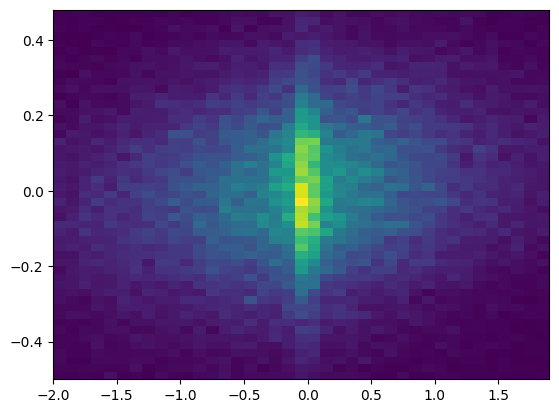

In [178]:
plt.hist2d(Y,X2@A,bins =[np.arange(-2,2,0.1), np.arange(-0.5,0.5,0.02)]);

In [179]:
torch.corrcoef( torch.stack((Y,X2@A)) )

tensor([[1.0000, 0.1918],
        [0.1918, 1.0000]])

In [158]:
(Y).std()

tensor(1.1161)

In [157]:
(Y-X@A).std()

tensor(1.0954)

In [211]:
X2=X-X.mean(dim=0)

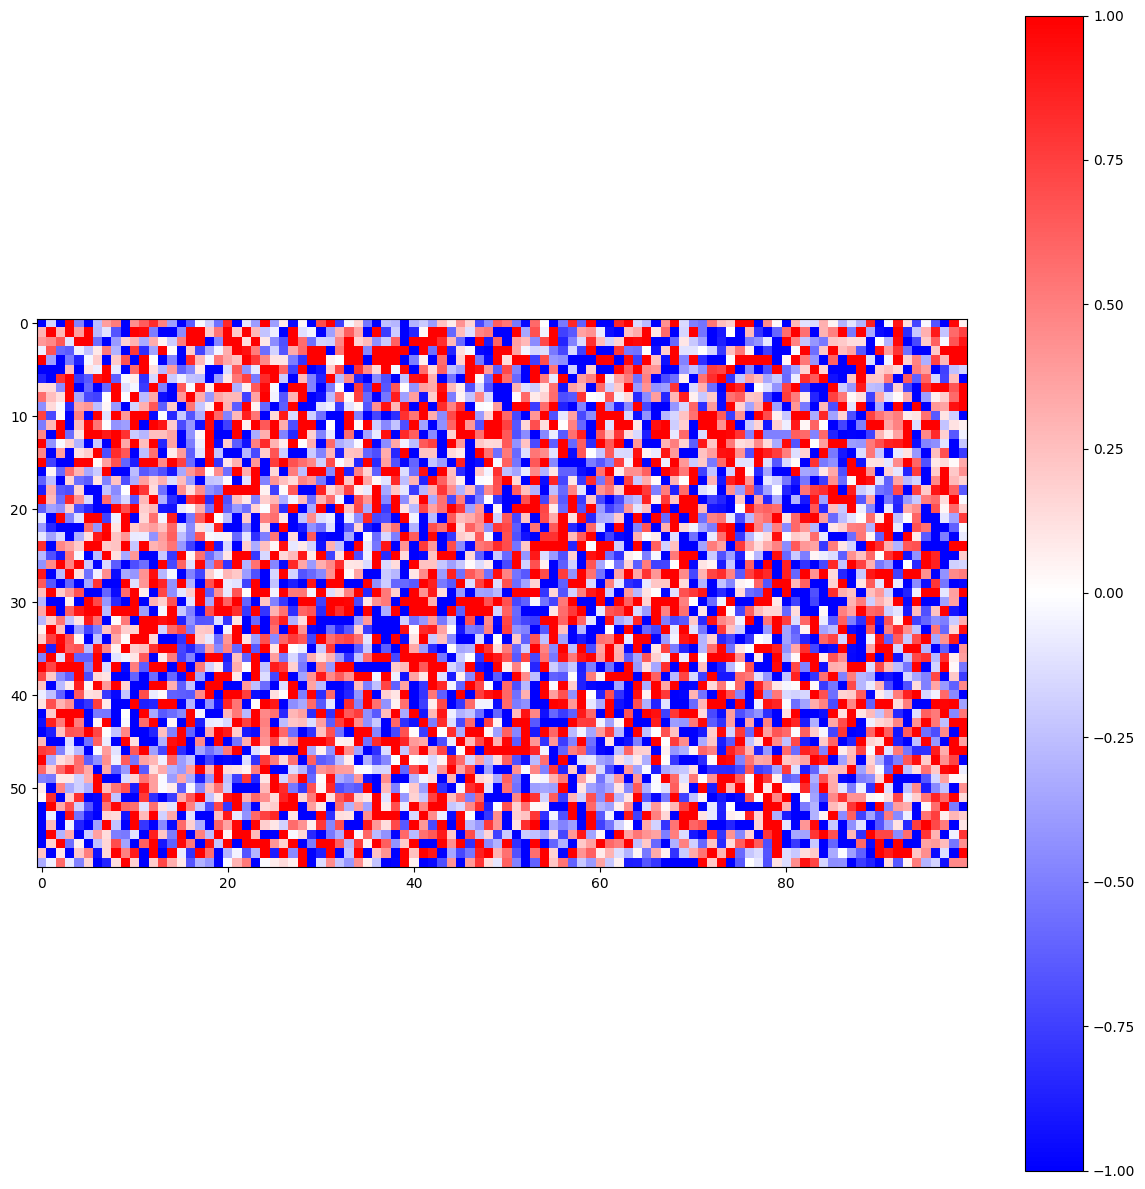

In [173]:
plt.figure(figsize=(15,15))
plt.imshow(X2[0::1000,0:100].numpy(),cmap='bwr',vmin=-1,vmax=1)
plt.colorbar()

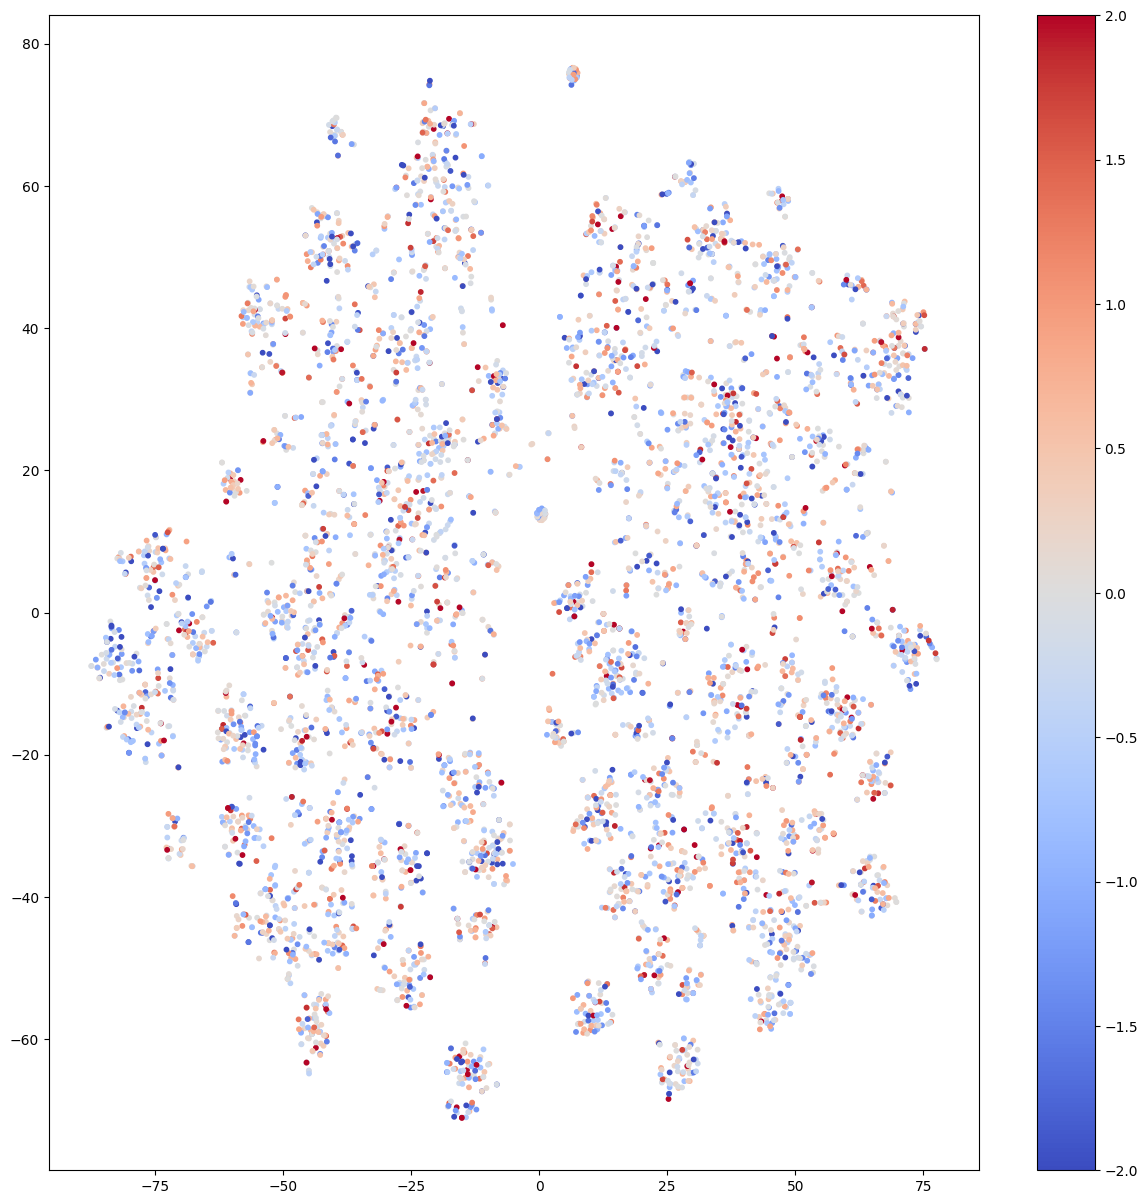

In [210]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X[0::11,:])
plt.figure(figsize=(15,15))
fig = plt.scatter(x=X_tsne[:, 0], y=X_tsne[:, 1], c=Y[0::11],cmap='coolwarm',s=10,vmin=-2,vmax=2)
plt.colorbar()

In [228]:
X2=X-X.mean(dim=0)
XN=X2/torch.norm(X2,dim=1).unsqueeze(1)
XN@XN[0,:]

tensor([ 1.0000,  0.1158, -0.3498,  ..., -0.3597,  0.2603,  0.2564])

In [231]:
XN.norm(dim=1)

tensor([1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000])

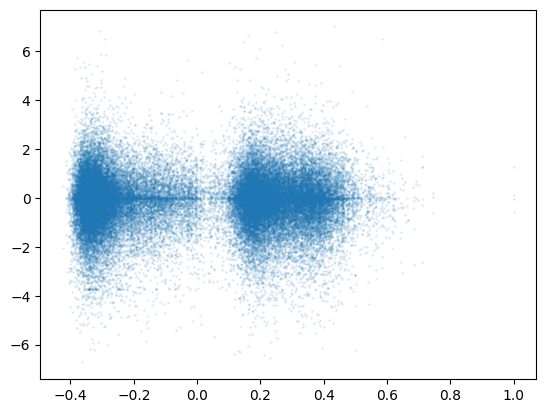

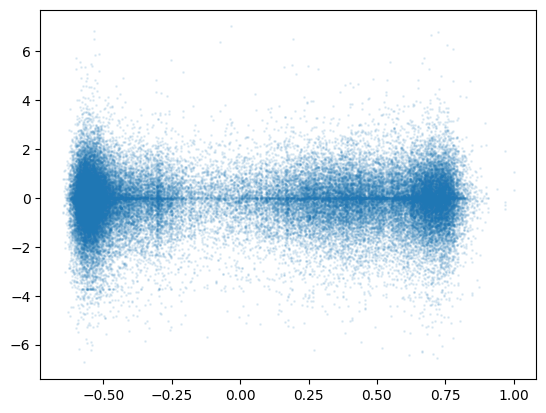

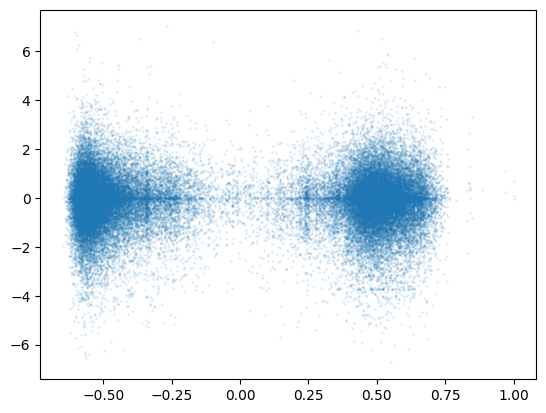

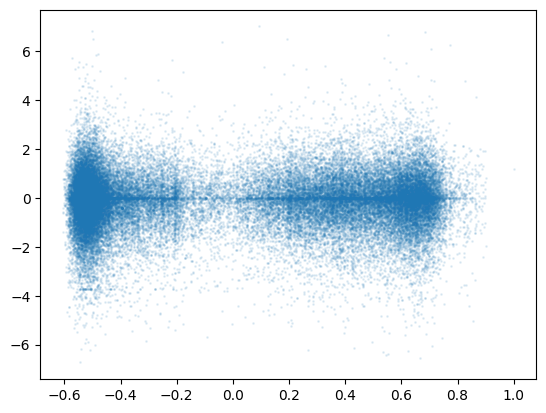

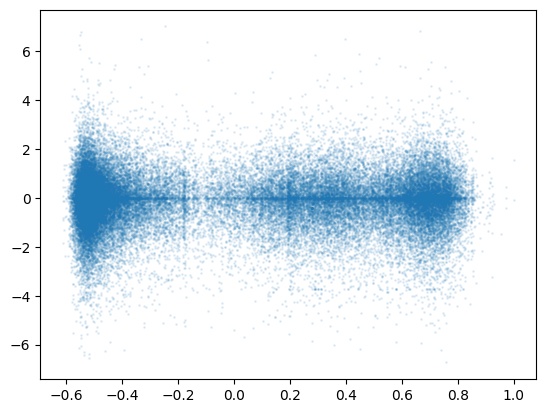

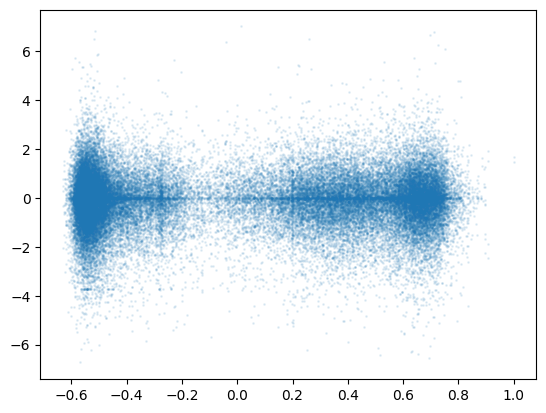

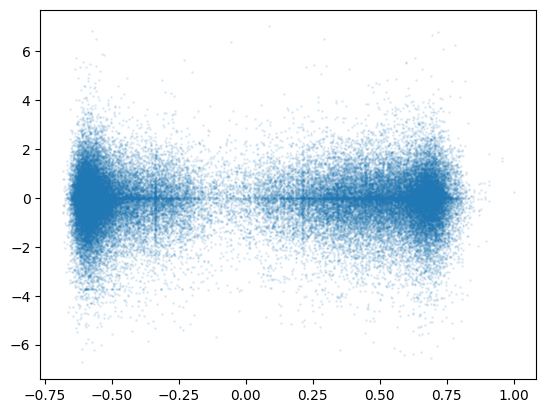

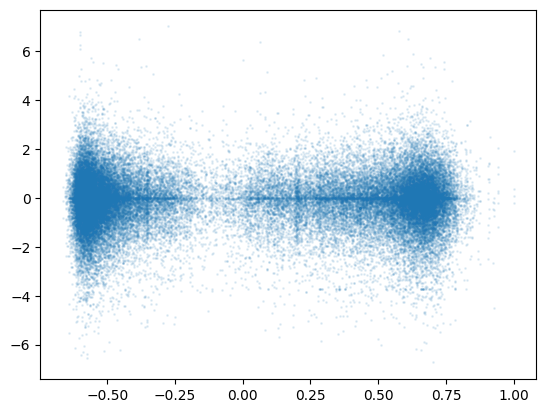

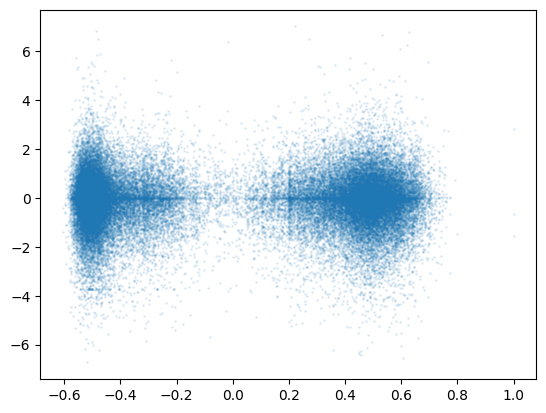

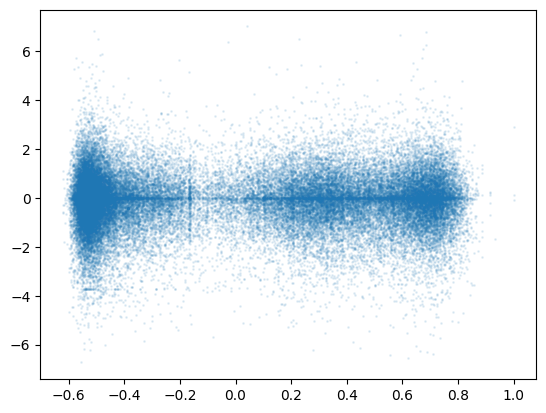

In [234]:
for i in range(0,1000,100):
    plt.figure()
    plt.scatter(XN@XN[i,:],Y,s=1,alpha=0.1)

## Generating the index

In [252]:
residuals.shape

torch.Size([28000, 1024, 10])

In [255]:
ex.dtype

torch.int64

In [55]:
import threading
import os
import time

def generate_index(token_ids, path='/igli/token_index_data'):
    if isinstance(token_ids, int):
        token_ids = [token_ids]
    for token_of_interest in token_ids:
        all3 = ((ID[:, 0][..., None, None] != 0) *(T_ID == token_of_interest)).nonzero()
        if len(all3) == 0:
            continue
        ex, ps, top10id = all3[:,0], all3[:,1], all3[:,2]
        Y = residuals[ex, ps, top10id]
        P = approximate_probs[ex, ps, top10id]
        file_nums = ex // 1000 + 1

        locations = torch.concatenate((file_nums.unsqueeze(1), ps.unsqueeze(1)), dim=1).numpy().astype('uint16')
        locations.tofile(os.path.join(path, f'{token_of_interest:06d}_locations'))

        data = torch.concatenate((Y.unsqueeze(1), P.unsqueeze(1)), dim=1).numpy()
        data.tofile(os.path.join(path, f'{token_of_interest:06d}_data'))

t1 = time.time()
token_ids = list(range(256000))
num_threads = 64
threads = [threading.Thread(target=generate_index, args=(token_ids[i::num_threads],'/igli/token_index_data')) for i in range(num_threads)]
for thread in threads:
    thread.start()
# for thread in threads:
#     thread.join()
t2 = time.time()
print("Done parallel", t2-t1)


Done parallel 10.32722544670105


# Training the embedding layer

In [163]:
class linearlayer(torch.nn.Module):
    def __init__(self, token_id, device, embedding_size = 2048):
        super(linearlayer, self).__init__()
        self.embedding_size = embedding_size
        self.token_of_interest = token_id
        self.linear1 =torch.nn.Linear(self.embedding_size, 1, device=device,dtype=torch.float32,bias=False)
        
        with torch.no_grad():
            self.linear1.weight.data=(self.linear1.weight*0)
    
        self.device=device
    
    def forward(self, input_embs, res_prob, teacher_prob):
        input_embs = input_embs.to(torch.float32)
        res_prob = res_prob.to(torch.float32)
        teacher_prob = teacher_prob.to(torch.float32)
        y = self.linear1(input_embs)
        loss = torch.abs(res_prob - y)
        loss = loss * teacher_prob
        return y, loss


In [161]:
token_of_interest = 7900 # ['▁theory']
token_7257_data = EmbeddingsDataset(token_of_interest, device = 'cuda:1', emb_size=2048)


In [46]:
token_7257_data.informations

{'embeddings': array([[-0.9375 , -0.969  , -0.788  , ..., -0.3357 ,  0.8257 ,  1.155  ],
        [ 0.3674 ,  1.046  , -0.542  , ..., -1.158  , -0.9453 ,  3.309  ],
        [ 0.642  , -0.1722 ,  0.062  , ..., -0.7183 ,  0.4138 ,  1.007  ],
        ...,
        [-1.68   ,  0.38   , -0.362  , ..., -0.971  , -0.02568,  0.809  ],
        [ 0.4463 , -2.06   ,  1.286  , ..., -0.3909 ,  0.584  , -0.6157 ],
        [ 0.03096, -0.889  ,  1.548  , ..., -1.288  , -0.999  ,  0.04395]],
       dtype=float16),
 'example_id': tensor([    2,     2,     2,  ..., 27998, 27998, 27998]),
 'positions': tensor([  17,  468,  656,  ...,  798,  805, 1007])}

tensor([    2,     2,     2,  ..., 27998, 27998, 27998])

torch.Size([58237])

(58237, 2048)

tensor([  17,  468,  656,  ...,  798,  805, 1007])

In [20]:
teacher_probs = torch.softmax(TL, dim=-1)
student_probs = torch.softmax(SL, dim=-1)
residual_probs = teacher_probs - student_probs

In [25]:
loop.set_postfix_str("loss")


lo

In [35]:
model = linearlayer(token_of_interest, 'cuda:1')

In [41]:
token_7257_data

In [57]:
np.arange(3)

array([0, 1, 2])

In [103]:
T_ID, residuals, residual_probs = map(lambda x : x.to('cuda:1'), [T_ID, residuals, residual_probs])

In [110]:
residual_logit.device

device(type='cuda', index=1)

In [157]:
(torch.tensor(0.5, dtype=torch.float32) * torch.tensor(0.4, dtype=torch.float16)).dtype

torch.float32

In [314]:
class multi_embedding(torch.nn.Module):
    def __init__(self, token_id, device, embedding_size = 2048, number_of_clusters = 2):
        super(multi_embedding, self).__init__()
        self.number_of_clusters=number_of_clusters
        self.embedding_size = embedding_size
        self.normalization_factor = torch.sqrt(torch.tensor(self.embedding_size).to(device))
        self.token_of_interest = token_id
        self.linear1 =torch.nn.Linear(self.embedding_size, self.number_of_clusters, device=device,dtype=torch.float32,bias=False)
        # self.linear2 =torch.nn.Linear(self.number_of_clusters, 1, device=device,dtype=torch.float32,bias=False)
        # with torch.no_grad():
        #     self.linear1.weight.data=(self.linear1.weight*0.01)

        self.device=device
        self.relu=torch.nn.ReLU()
    
    def forward(self, input_embs, res_prob, teacher_prob):
        input_embs = input_embs.to(torch.float32)
        res_prob = res_prob.to(torch.float32)
        teacher_prob = teacher_prob.to(torch.float32)
        # print('input_embs',input_embs.shape)
        scores = self.linear1(input_embs)
        scores/=self.normalization_factor
        #print('scores',scores.shape)
        # ps=torch.softmax(scores,dim=-1)
        ps=self.relu(scores)
        # print(ps)
        #print('ps',ps.shape)
        # y =self.linear2(ps)/50
        y =(ps[:,0:self.number_of_clusters//2].sum(dim=-1,keepdims=True)-ps[:,self.number_of_clusters//2:self.number_of_clusters].sum(dim=-1,keepdims=True))
        # print('y',y.shape)
        loss = torch.abs ((res_prob- y))
        loss = loss * teacher_prob
        return y, loss


tensor(45.2548, device='cuda:1')

In [295]:
model = multi_embedding(token_of_interest, 'cuda:1')
output=model(embeddings, label.unsqueeze(1), tp.unsqueeze(1))


In [296]:
output[0]

tensor([[ 0.0000],
        [ 0.0000],
        [ 0.0000],
        ...,
        [ 0.0000],
        [-0.0057],
        [ 0.0000]], device='cuda:1', grad_fn=<SubBackward0>)

In [283]:
label

tensor([ 0.0268, -0.0422,  0.0257,  ...,  0.0095,  0.0036,  0.0287],
       device='cuda:1', dtype=torch.float16)

In [320]:
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import datetime
import time

# hyperparams = {
#     'lr' : 3e-8,
#     # 'target' : 'logit',        # residual logit or residual probability
#     'target' : 'probability',  
#     'weighted' : True,         # whether to multiply loss with parent probability or not 
#     'optimizer' : 'Adam',
#     'batch_size':  10000
# }

hyperparams = {
    'lr' : 1,
    # 'target' : 'logit',        # residual logit or residual probability
    'target' : 'probability',  
    'weighted' : True,         # whether to multiply loss with parent probability or not 
    'optimizer' : 'SGD',
    'batch_size':  10000
}


torch.manual_seed(0)

#model = linearlayer(token_of_interest, 'cuda:1')
model = multi_embedding(token_of_interest, 'cuda:1',number_of_clusters=100)

optimizer = optim.SGD(model.parameters(), lr=hyperparams['lr'])#,momentum=0
#optimizer = optim.Adam(model.parameters(), lr=hyperparams['lr'])
n_epochs = 5000
experiment_name = "multi_cluster_center10"
location = f'tensorboard/{hyperparams["target"]}/{experiment_name}_{hyperparams}'

writer = SummaryWriter(location)

tall=0
batch_size=np.minimum(hyperparams['batch_size'], len(token_7257_data))

# loader = torch.utils.data.DataLoader(token_7257_data, batch_size=10000, shuffle=False, collate_fn=collate)
loop = tqdm(range(n_epochs), desc="Progress")
for epoch in loop:
    epoch_loss = 0
    for i in np.arange(len(token_7257_data)/batch_size, dtype=np.int8):
        
        # embeddings = sample['embedding']
        # example_ids = sample['example_id']
        # token_pos = sample['token_pos']
        
        start=i*batch_size;
        end  =start+batch_size
        if start==len(token_7257_data): continue
        example_ids=(token_7257_data.informations['example_id'][start:end]  )
        token_pos  =(token_7257_data.informations['positions' ][start:end]  )
        embeddings =(token_7257_data.informations['embeddings'][start:end,:])
        
        # Get residual probabilities to pass to the model
        
        t0=time.time()
        token_of_interest_rank = (T_ID[example_ids, token_pos] == token_of_interest).nonzero()[:, 1] # TODO: pre-compute this and make this part of the dataset
        optimizer.step()
        # residual_logit = residuals[example_ids, token_pos, token_of_interest_rank]
        
        residual_prob = residual_probs[example_ids, token_pos, token_of_interest_rank]
        
        # if hyperparams['target'] == 'logit':
        #     label = residual_logit
        # else:
        label = residual_prob

        
        # Get teacher probabilities to pass to the model
        if hyperparams['weighted']:
            tp = teacher_probs[example_ids, token_pos, token_of_interest_rank]
        else:
            tp = torch.ones_like(label)
          
        
        output, loss = model(embeddings, label.unsqueeze(1)*100, tp.unsqueeze(1))
        # Batched loss
        
        loss.mean().backward()
        epoch_loss += loss.sum().item()
        tall+=time.time()-t0
        
        
    # print(model.linear2.weight.mean().detach().cpu().numpy())
    epoch_loss = epoch_loss/(len(token_7257_data))
    writer.add_scalar('Average Epoch Loss', epoch_loss, epoch)
    # loop.set_postfix_str(f"Loss {epoch_loss:04f}")
# print('time',tall)


Progress: 100%|█| 5000/5000 [01:04<00
